In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("MICRODADOS_ENEM_2023_trabalhado.csv")

In [5]:
df.shape

(2166843, 65)

In [6]:
colunas_uteis = [
    'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO',
    'SG_UF_PROVA', 'TP_ESCOLA', 'Q006', 'TP_PRESENCA_MT'
]

In [7]:
df = df[colunas_uteis]
df.head()

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,SG_UF_PROVA,TP_ESCOLA,Q006,TP_PRESENCA_MT
0,502.0,498.9,475.6,363.2,700.0,RS,1,C,1
1,459.0,508.5,507.2,466.7,880.0,CE,2,C,1
2,402.5,379.2,446.9,338.3,560.0,CE,2,B,1
3,564.7,630.3,610.4,680.2,600.0,SP,1,F,1
4,644.9,620.2,626.9,736.3,860.0,RN,1,B,1


In [8]:
df.isnull().sum()

NU_NOTA_CN         0
NU_NOTA_CH         0
NU_NOTA_LC         0
NU_NOTA_MT         0
NU_NOTA_REDACAO    0
SG_UF_PROVA        0
TP_ESCOLA          0
Q006               0
TP_PRESENCA_MT     0
dtype: int64

In [9]:
df[df['TP_PRESENCA_MT'] != 1]['NU_NOTA_MT'].isnull().sum()
df[df['TP_PRESENCA_MT'] == 1]['NU_NOTA_MT'].isnull().sum()

0

In [10]:
df.groupby('SG_UF_PROVA')['NU_NOTA_MT'].mean().sort_values(ascending = False)

SG_UF_PROVA
SP    568.781838
MG    567.497639
SC    560.263875
RS    556.608589
ES    552.695389
PR    552.057949
DF    550.696603
RJ    548.626840
GO    533.622564
PE    526.328323
MS    526.193247
RN    524.998899
RR    521.396260
CE    520.769656
MT    514.356972
PB    512.586118
SE    510.693415
AL    505.457504
BA    505.019654
PI    503.797632
TO    503.496124
RO    499.343117
AC    488.067552
PA    484.214692
MA    482.825722
AM    481.762989
AP    480.813356
Name: NU_NOTA_MT, dtype: float64

In [11]:
df.groupby('SG_UF_PROVA')['NU_NOTA_REDACAO'].mean().sort_values(ascending = False)

SG_UF_PROVA
MG    662.230107
ES    647.638364
RJ    641.191270
SP    641.131676
SE    640.981618
SC    640.717972
GO    640.551227
RS    638.784411
DF    636.339559
RN    627.257475
PE    624.806226
PB    624.596809
PI    619.828381
PR    616.403536
BA    614.049748
CE    613.575838
TO    608.897112
MS    605.972605
RR    604.097237
AL    603.557435
MT    599.305206
PA    598.529902
MA    593.567267
RO    592.815355
AC    590.087512
AP    582.530283
AM    549.279332
Name: NU_NOTA_REDACAO, dtype: float64

In [12]:
df.groupby('Q006')['NU_NOTA_MT'].mean()

Q006
A    454.547518
B    476.846644
C    511.096275
D    531.899849
E    552.107561
F    572.411086
G    589.880446
H    610.782520
I    623.614873
J    636.318707
K    646.755277
L    655.759971
M    664.539845
N    670.702719
O    681.832844
P    694.145652
Q    707.309395
Name: NU_NOTA_MT, dtype: float64

In [13]:
notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

In [14]:
print(df.groupby('Q006')[notas].mean())

      NU_NOTA_CN  NU_NOTA_CH  NU_NOTA_LC  NU_NOTA_MT  NU_NOTA_REDACAO
Q006                                                                 
A     454.316710  479.478681  476.442110  454.547518       532.316515
B     465.458101  494.448368  492.115466  476.846644       570.743210
C     484.898147  517.606776  513.279346  511.096275       602.498982
D     496.620038  530.185825  524.312494  531.899849       623.963826
E     507.690965  540.876483  533.881149  552.107561       646.774349
F     517.937519  550.421635  541.612833  572.411086       666.485369
G     528.637833  560.451782  549.666266  589.880446       687.379149
H     540.745038  571.237227  558.379336  610.782520       709.928299
I     548.711613  577.857135  563.647594  623.614873       726.156684
J     557.025243  584.695744  569.037363  636.318707       739.815416
K     563.301507  588.496009  572.354346  646.755277       750.075796
L     568.121930  591.808799  575.292039  655.759971       756.470429
M     575.130348  59

In [15]:
df['NOTA_GERAL'] = df[notas].mean(axis = 1)

In [17]:
media_por_renda = df.groupby('Q006')['NOTA_GERAL'].mean()


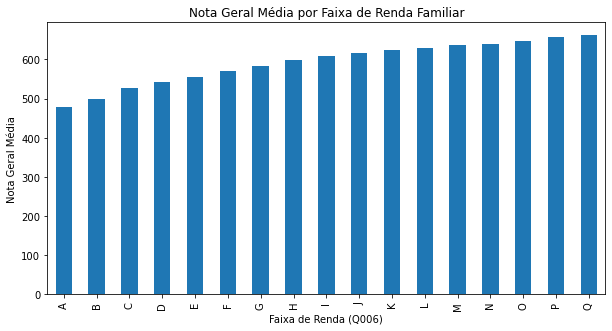

In [27]:
plt.figure(figsize=(10,5))
media_por_renda.plot(kind = 'bar')
plt.title('Nota Geral Média por Faixa de Renda Familiar')
plt.xlabel('Faixa de Renda (Q006)')
plt.ylabel('Nota Geral Média')
plt.show()

### Principais Insights do Gráfico:

* **Tendência de Crescimento Linear:** O gráfico de barras revela um comportamento estritamente ascendente. Conforme a renda familiar aumenta (da esquerda para a direita no eixo X), a nota média geral acompanha esse crescimento de forma proporcional.
* **Disparidade entre os Extremos (A vs. Q):** * Os candidatos situados na **Faixa A** apresentam a menor média observada, ficando abaixo da marca dos **500 pontos**.
    * Já os candidatos da **Faixa Q** atingem o patamar mais elevado do gráfico, superando a marca dos **650 pontos**.
* **A Desigualdade Educacional em Números:** A diferença entre o topo e a base da pirâmide de renda ultrapassa os **150 pontos na média geral**. Esse abismo numérico reflete as disparidades no acesso a insumos educacionais, escolas preparatórias, tempo dedicado exclusivamente aos estudos e segurança socioeconômica.

---

> **Conclusão:** Os dados comprovam empiricamente que **as notas do ENEM aumentam progressivamente conforme a renda familiar**. O gráfico é uma evidência visual clara de como fatores socioeconômicos moldam o desempenho acadêmico no cenário educacional brasileiro.

In [28]:
media_uf = df.groupby('SG_UF_PROVA')['NOTA_GERAL'].mean().sort_values(ascending = False)

In [30]:
print(media_uf)

SG_UF_PROVA
MG    566.366838
SP    563.344196
SC    559.464037
RS    557.443083
DF    556.847403
ES    555.280849
RJ    554.408583
PR    550.282417
GO    543.890798
RN    538.086528
PE    534.503049
RR    534.481039
MS    534.023807
SE    532.247455
PB    529.638142
CE    527.309432
MT    526.345600
BA    525.056801
PI    520.620951
TO    520.433458
AL    519.168847
RO    515.928804
AC    512.274821
PA    510.558160
AP    508.255656
MA    506.211410
AM    498.948785
Name: NOTA_GERAL, dtype: float64


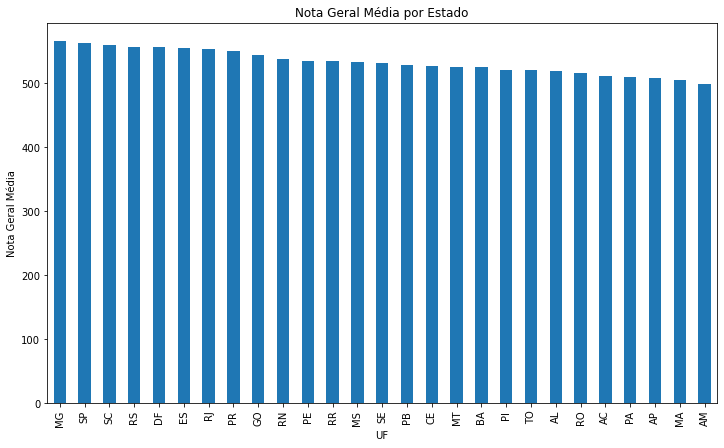

In [43]:
plt.figure(figsize=(12,7))
media_uf.plot(kind='bar')
plt.title('Nota Geral Média por Estado')
plt.xlabel('UF')
plt.ylabel('Nota Geral Média')
plt.xticks(rotation=90)
plt.show()

### Principais Insights do Gráfico:

* **Predomínio das Regiões Sudeste e Sul no Topo:** Os estados que lideram o ranking de nota média geral são **Minas Gerais (MG)** e **São Paulo (SP)**, seguidos de perto por **Santa Catarina (SC)** e **Rio Grande do Sul (RS)**, além do **Distrito Federal (DF)**. Esses estados mantêm médias consolidadas acima dos **550 pontos**.
* **Posição Intermediária de Goiás:** O estado de **Goiás (GO)** aparece logo em seguida, ocupando uma posição intermediária-alta no cenário nacional, superando a marca de estados tradicionais do Nordeste e Norte e mantendo um desempenho competitivo alinhado com a média do Centro-Oeste.
* **Disparidade Regional:** Há uma clara tendência decrescente no gráfico à medida que se avança para estados das regiões Norte e Nordeste. O extremo inferior do gráfico é ocupado pelo **Amazonas (AM)**, **Maranhão (MA)** e **Amapá (AP)**, cujas médias ficam próximas ou ligeiramente abaixo dos **500 pontos**.
* **Amplitude de Desempenho:** A diferença entre a maior média (MG) e a menor média (AM) evidencia que, além do fator socioeconômico individual, a infraestrutura educacional regional e fatores estruturais de cada estado impactam diretamente o resultado dos estudantes no exame.

---

> **Conclusão:** O gráfico de desempenho por UF expõe a persistência das **desigualdades regionais na educação brasileira**. Estados com maior concentração de renda, investimentos e infraestrutura escolar (Sul/Sudeste) continuam a apresentar médias sensivelmente superiores em comparação com estados das regiões Norte e Nordeste.

In [50]:
media_escola = df.groupby('TP_ESCOLA')['NOTA_GERAL'].mean().sort_values(ascending = False)

In [51]:
print(media_escola)

TP_ESCOLA
3    616.089247
1    543.891654
2    515.789085
Name: NOTA_GERAL, dtype: float64


In [ ]:
plt.figure(figsize=(8,5))
media_escola.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'])
plt.title('Nota Geral Média por Tipo de Escola')
plt.xlabel('Tipo de Escola (1=Não respondeu, 2=Pública, 3=Privada)')
plt.ylabel('Nota Geral Média')
plt.xticks(rotation=0)
plt.show()

### Principais Insights do Gráfico:

* **Vantagem expressiva do ensino privado:** Alunos de escolas privadas (código 3) lideram isoladamente o desempenho médio, com nota geral em torno de **616 pontos**.
* **Categoria "não respondeu" (código 1):** Candidatos que não informaram o tipo de escola apresentam média intermediária, próxima de **544 pontos**. É importante notar que esse grupo provavelmente reúne perfis variados (já formados há mais tempo, educação informal, etc.), e não deve ser interpretado como uma "rede de ensino".
* **Gargalo no ensino público:** Alunos de escolas públicas (código 2) registram a menor média entre as três categorias, em torno de **516 pontos**.

---

> **Conclusão:** Há uma diferença de aproximadamente **100 pontos** na nota geral média entre alunos de escolas privadas e públicas. Esse resultado é consistente com a literatura sobre desigualdade educacional no Brasil e reforça a importância de investimentos na rede pública de ensino médio.

## Conclusões Gerais

Este projeto analisou os microdados do ENEM 2023, explorando a relação entre o desempenho dos candidatos (nota geral média, calculada a partir das 5 provas) e três fatores: renda familiar, estado (UF) e tipo de escola.

**1. Renda familiar:** Existe uma relação clara e crescente entre renda familiar (Q006) e desempenho. Candidatos na faixa de renda mais baixa (A) têm nota geral média abaixo de 500 pontos, enquanto os da faixa mais alta (Q) superam 650 pontos — uma diferença de mais de 150 pontos.

**2. Região (UF):** Estados das regiões Sul e Sudeste (MG, SP, SC, RS, DF) apresentam as maiores médias, acima de 550 pontos. Estados do Norte e Nordeste (AM, MA, AP) ficam na faixa de 500 pontos ou abaixo, evidenciando desigualdade regional no acesso à educação de qualidade.

**3. Tipo de escola:** A diferença entre alunos de escolas privadas (~616 pontos) e públicas (~516 pontos) é de aproximadamente 100 pontos, reforçando o impacto da rede de ensino no desempenho.

**Limitações:**
- A análise é descritiva (médias e comparações), não há testes estatísticos de significância nem controle por outras variáveis (ex: pode haver correlação entre renda, UF e tipo de escola que não foi isolada).
- A categoria "não respondeu" em TP_ESCOLA pode incluir perfis heterogêneos.

**Próximos passos possíveis:**
- Aplicar testes estatísticos (ex: ANOVA) para validar se as diferenças observadas são estatisticamente significativas.
- Cruzar renda + tipo de escola + UF para entender qual fator pesa mais.
- Analisar separadamente cada uma das 5 provas (não só a nota geral) para ver se o padrão se mantém em todas as áreas.